# Anomally Detection : Manual vs Automatic (sklearn)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.datasets import make_blobs

np.random.seed(42)

## Create Random data

In [7]:
#The underscore _ ignores the labels returned by make_blobs, since we’ll create our own labels later.
X_normal , _ = make_blobs(n_samples=300,centers=[[2,2],[-2,-2]],cluster_std=0.8,random_state=42) 
X_anomalies = np.random.uniform(low=-8, high=8, size=(25, 2))

X = np.vstack([X_normal, X_anomalies])

#Assign label 0 to normal data (300 samples).
#Assign label 1 to anomaly data (25 samples).
y_true = np.array([0] * len(X_normal) + [1] * len(X_anomalies)) 

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y_true, test_size=0.4,random_state=42, stratify=y_true) # Stratify for uniform split

print(f"Total data shape: {X.shape}")
print(f"Training data shape (X_train): {X_train.shape}")
print(f"Validation data shape (X_val): {X_val.shape}")
print(f"Validation labels (anomalies): {np.sum(y_val)} out of {len(y_val)}")

Total data shape: (325, 2)
Training data shape (X_train): (195, 2)
Validation data shape (X_val): (130, 2)
Validation labels (anomalies): 10 out of 130


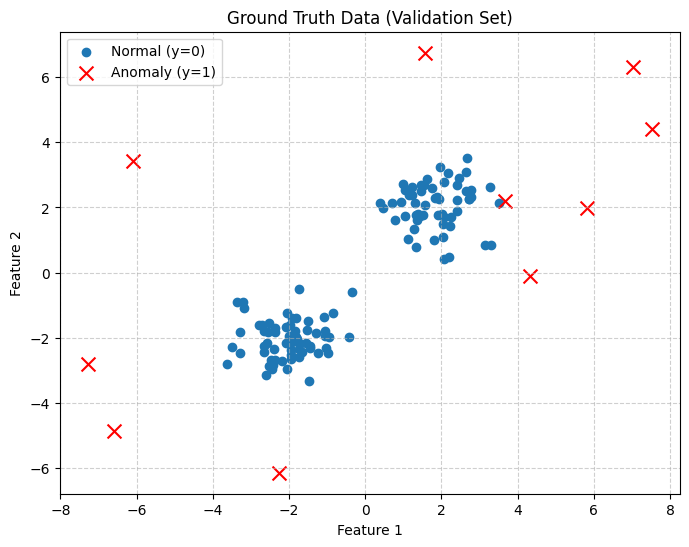

In [9]:
plt.figure(figsize=(8, 6))
plt.title("Ground Truth Data (Validation Set)")
plt.scatter(X_val[y_val==0, 0], X_val[y_val==0, 1], label="Normal (y=0)")
plt.scatter(X_val[y_val==1, 0], X_val[y_val==1, 1], label="Anomaly (y=1)", 
            marker='x', c='r', s=100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Manual gaussian method